In [19]:
%matplotlib widget

In [20]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [21]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [22]:
image_cut = image[55:155, 0:1890]
image_error_cut = image_error[55:155, 0:1890]

In [23]:
wavelengths = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelengths, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

Text(0.5, 45.40277777777776, 'wavelength')

In [24]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/PSF/Real_seeing_Mrk544.txt")
sigma = seeing[0] / 2.35

In [25]:
l_HA

6719.1994

Text(0.5, 1.0, 'H$\\alpha$')

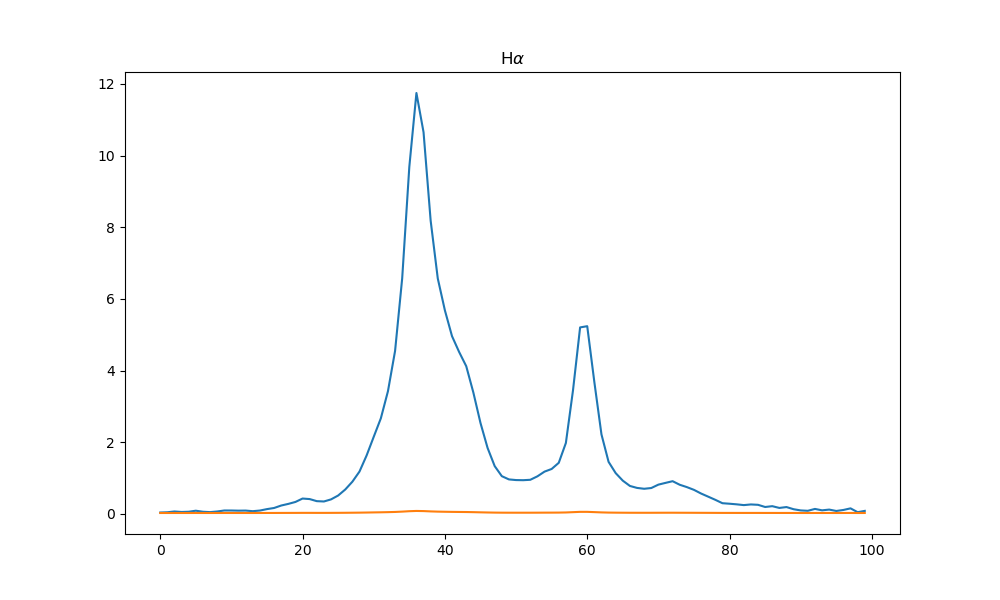

In [26]:
#Ogni punto del flusso è il risultato della somma di 20 lunghezze d'onda 
mask_HA = (wavelengths > l_HA-8)*(wavelengths < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [27]:
sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Propagazione_errori/Sky_errors.txt")
real_errors = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

In [28]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

#Define the function for the aic
#Per l'AIC test usiamo il chi quadro perchè il numero di conteggi è elevato (S/N grande) 
#quindi Poisson --> Gauss
#def chi_quad(x, y, y_err, params):
#    return np.sum((((y - model_convolved(x, *params)) / y_err)**2))
    
def AIC(x, y, chi, params): #k=number of model parameter, N=number of data points
    return chi + 2*len(params) +((2*len(params)*(len(params)+1))/(len(y)-len(params)-1))

def BIC(x, y, chi, params):
        return chi + len(params)*np.log(len(y))
    
def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, chi2

In [29]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params) 
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 40),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params1 = result.x

print("Optimize parameters with differential_evolution:", best_params1)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 181.88950895330944
differential_evolution step 2: f(x)= 178.29929894085666
differential_evolution step 3: f(x)= 132.31519368545855
differential_evolution step 4: f(x)= 121.05166748422343
differential_evolution step 5: f(x)= 121.05166748422343
differential_evolution step 6: f(x)= 120.8337663303664
differential_evolution step 7: f(x)= 119.36101168988162
differential_evolution step 8: f(x)= 119.36101168988162
differential_evolution step 9: f(x)= 110.6908484661957
differential_evolution step 10: f(x)= 110.6908484661957
differential_evolution step 11: f(x)= 110.6908484661957
differential_evolution step 12: f(x)= 110.6908484661957
differential_evolution step 13: f(x)= 110.6908484661957
differential_evolution step 14: f(x)= 110.6908484661957
differential_evolution step 15: f(x)= 107.17732346811393
differential_evolution step 16: f(x)= 107.17732346811393
differential_evolution step 17: f(x)= 107.17732346811393
differential_evolution step 18: f(x)= 107.17732

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0983, r_e=59.0013, n=3.3776, x_0=37.3232
[ 0.11689319 48.44137477  1.01699737  0.34136203]
50.68074851595302
59.101801147531965 0.0 69.10142925990539 4


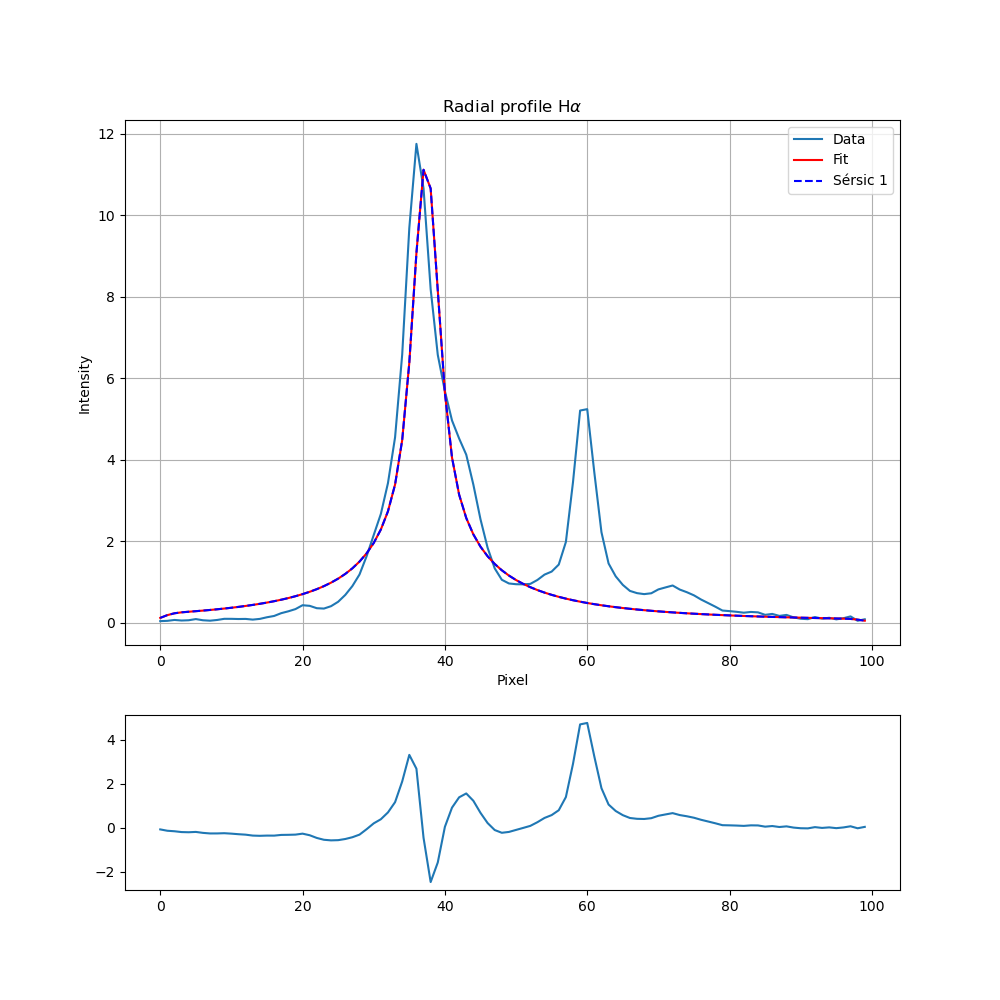

In [30]:
aic = np.zeros(6)
bic = np.zeros(6)
chi_quadr = np.zeros(6)
chi_quadro = np.zeros(6)
red_chi = np.zeros(6)

params_curve_1, covariance_1 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params1,
                                         sigma = real_errors, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi_quadr[0], red_chi[0] = save_params(params_curve_1, covariance_1, radial_profile_HA, real_errors, x_axes, 1, line_name="One", 
                                           output_prefix="fit")

aic[0] = AIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
bic[0] = BIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
print(aic[0], chi_quadro[0], bic[0], len(params_curve_1))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_1), 'b--', label='Sérsic 1')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_1')

In [31]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (33, 38),   # x_0: posizione da 0 a 100   # x_0: posizione da 0 a 100
    
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (55, 65),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params2 = result.x

print("Optimize parameters with differential_evolution:", best_params2)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 92.59470443910068
differential_evolution step 2: f(x)= 92.59470443910068
differential_evolution step 3: f(x)= 78.35619646883333
differential_evolution step 4: f(x)= 78.35619646883333
differential_evolution step 5: f(x)= 71.11991530621826
differential_evolution step 6: f(x)= 71.11991530621826
differential_evolution step 7: f(x)= 44.36592305209275
differential_evolution step 8: f(x)= 44.36592305209275
differential_evolution step 9: f(x)= 44.36592305209275
differential_evolution step 10: f(x)= 41.05221983760891
differential_evolution step 11: f(x)= 41.05221983760891
differential_evolution step 12: f(x)= 41.05221983760891
differential_evolution step 13: f(x)= 35.51058975780161
differential_evolution step 14: f(x)= 35.51058975780161
differential_evolution step 15: f(x)= 35.51058975780161
differential_evolution step 16: f(x)= 35.51058975780161
differential_evolution step 17: f(x)= 35.51058975780161
differential_evolution step 18: f(x)= 35.51058975780161
d

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18716\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18716\72937070.py:8: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.1273, r_e=35.5378, n=3.5213, x_0=36.8707
Sérsic 2: I_e=0.0247, r_e=61.2796, n=3.8401, x_0=59.6129
[1.45641751e-01 2.88008073e+01 9.61892625e-01 1.56927865e-01
 1.12764165e-01 1.94084443e+02 4.60274756e+00 4.90622491e-04]
15.107803600137451
32.690221182555035 15.107803600137451 51.949165088042186 8


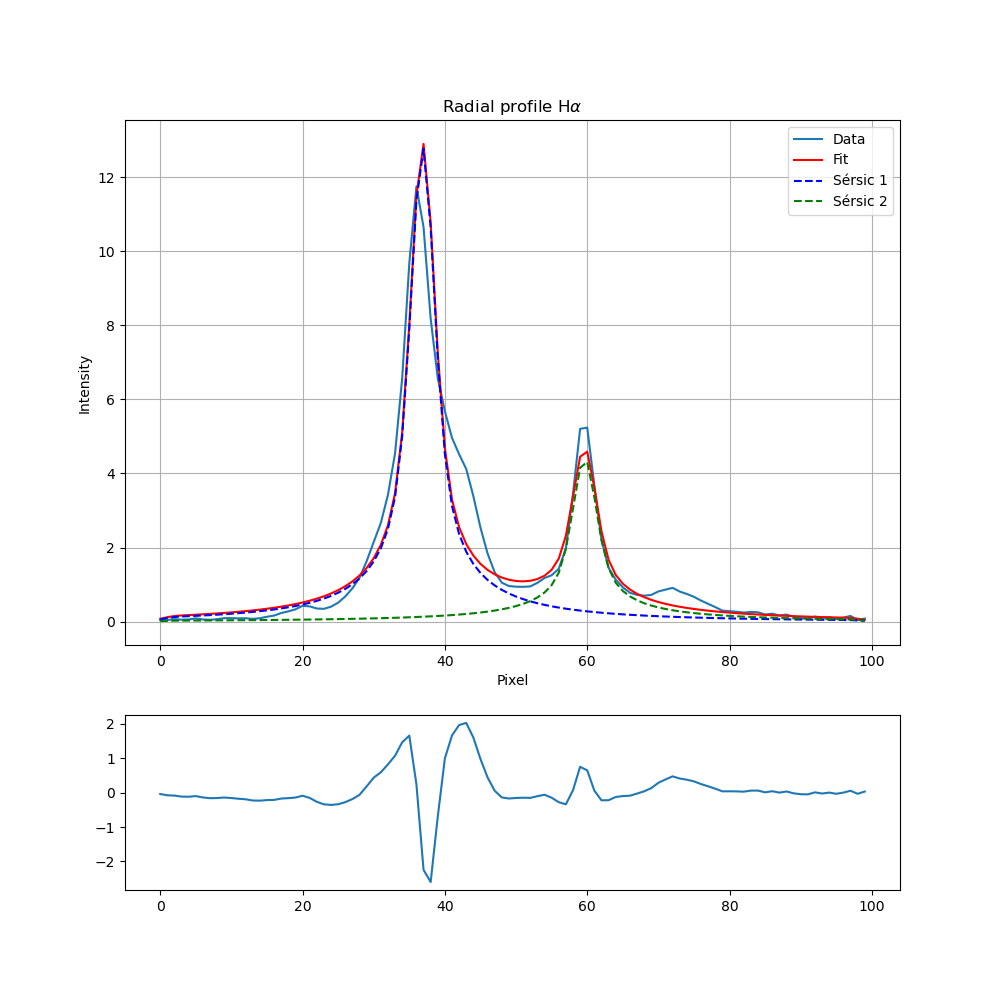

In [32]:
# Plots:
params_curve_2, covariance_2 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params2, 
                                         sigma = real_errors)

print("Optimize parameters with curve fit:")

chi_quadr[1], red_chi[1] = save_params(params_curve_2, covariance_2, radial_profile_HA, real_errors,
    x_axes, 2, line_name="Two", output_prefix="fit")

aic[1] = AIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
bic[1] = BIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
print(aic[1], chi_quadr[1], bic[1], len(params_curve_2))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[4:8]), 'g--', label='Sérsic 2')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_2')

In [33]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (33, 38),   # x_0: posizione da 0 a 100   # x_0: posizione da 0 a 100
    
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (55, 65),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (68, 73),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params3 = result.x

print("Optimize parameters with differential_evolution:", best_params3)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 227.3733270173685
differential_evolution step 2: f(x)= 184.18716884715957
differential_evolution step 3: f(x)= 184.18716884715957
differential_evolution step 4: f(x)= 166.24520988098286
differential_evolution step 5: f(x)= 114.05280390524153
differential_evolution step 6: f(x)= 100.7680515713048
differential_evolution step 7: f(x)= 100.7680515713048
differential_evolution step 8: f(x)= 100.7680515713048
differential_evolution step 9: f(x)= 61.900361735027694
differential_evolution step 10: f(x)= 61.900361735027694
differential_evolution step 11: f(x)= 61.900361735027694
differential_evolution step 12: f(x)= 61.900361735027694
differential_evolution step 13: f(x)= 61.900361735027694
differential_evolution step 14: f(x)= 61.900361735027694
differential_evolution step 15: f(x)= 61.900361735027694
differential_evolution step 16: f(x)= 61.900361735027694
differential_evolution step 17: f(x)= 55.9606305519556
differential_evolution step 18: f(x)= 55.96063

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18716\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18716\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18716\3846609059.py:9: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)


Optimize parameters with curve fit:
Sérsic 1: I_e=0.1242, r_e=32.5988, n=3.5811, x_0=36.5843
Sérsic 2: I_e=0.0188, r_e=16.1120, n=5.1471, x_0=59.5881
Sérsic 3: I_e=0.4379, r_e=23.6702, n=0.0652, x_0=53.8212
[1.72469696e-01 2.95639746e+01 1.48469888e+00 1.17289362e-01
 5.65913819e-01 2.99868430e+02 4.51628012e+01 4.95876654e-04
 4.16250402e-01 4.54238793e+00 5.82303628e-02 1.04582945e+00]
9.397900509371716
36.98410740592344 9.397900509371716 64.65994274122882 12


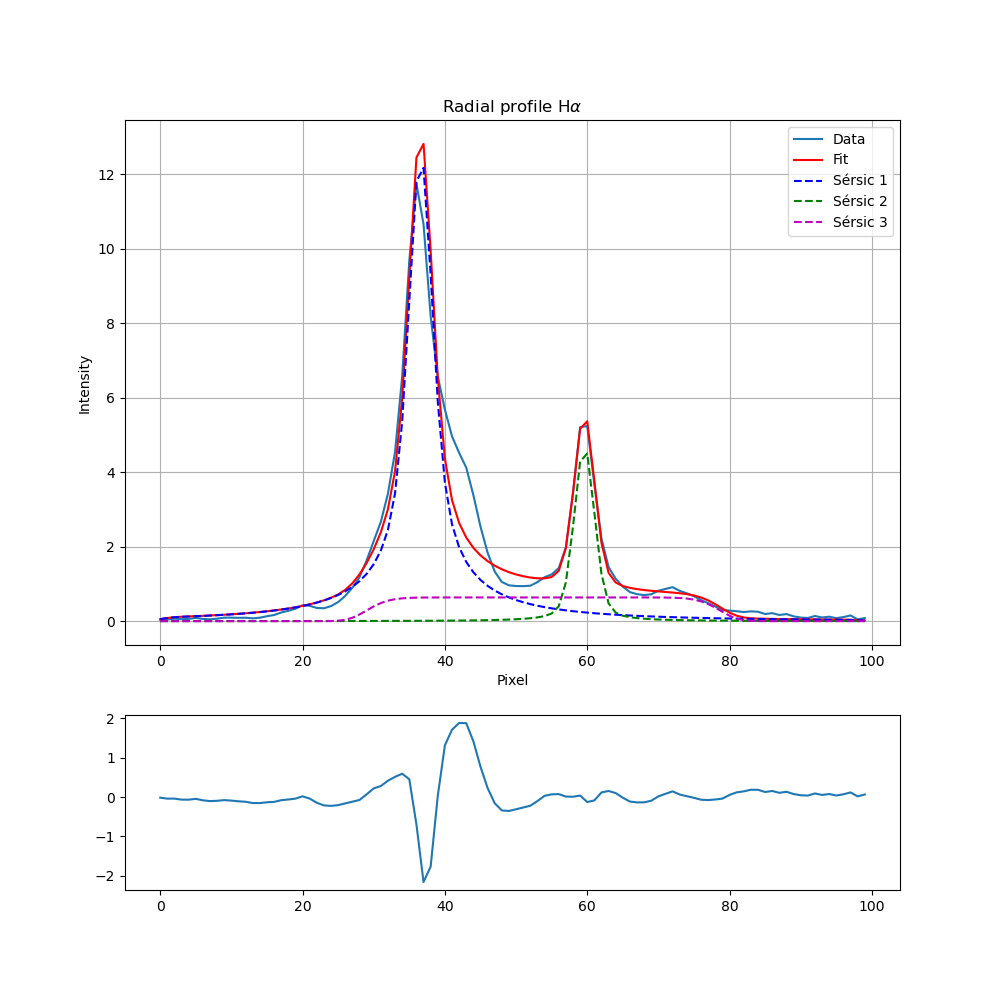

In [34]:
# Plots:
params_curve_3, covariance_3 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params3, 
                                         sigma = real_errors)

print("Optimize parameters with curve fit:")

chi_quadr[2], red_chi[2] = save_params(params_curve_3, covariance_3, radial_profile_HA, real_errors,x_axes, 3,  
                                       line_name="Three", output_prefix="fit")

aic[2] = AIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
bic[2] = BIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
print(aic[2], chi_quadr[2], bic[2], len(params_curve_3))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_3)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[8:12]), 'm--', label='Sérsic 3')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_3')

In [35]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (50, 70),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (70, 80)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params4 = result.x

print("Optimize parameters with differential_evolution:", best_params4)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 37060.79405794011
differential_evolution step 2: f(x)= 25808.305523818937
differential_evolution step 3: f(x)= 9349.64303520498
differential_evolution step 4: f(x)= 9349.64303520498
differential_evolution step 5: f(x)= 1546.5745760903917
differential_evolution step 6: f(x)= 1546.5745760903917
differential_evolution step 7: f(x)= 666.9288192784655
differential_evolution step 8: f(x)= 666.9288192784655
differential_evolution step 9: f(x)= 567.135793316232
differential_evolution step 10: f(x)= 567.135793316232
differential_evolution step 11: f(x)= 567.135793316232
differential_evolution step 12: f(x)= 437.70048358629646
differential_evolution step 13: f(x)= 437.70048358629646
differential_evolution step 14: f(x)= 437.70048358629646
differential_evolution step 15: f(x)= 437.70048358629646
differential_evolution step 16: f(x)= 437.70048358629646
differential_evolution step 17: f(x)= 437.70048358629646
differential_evolution step 18: f(x)= 437.70048358629

Optimize parameters with curve fit:
Sérsic 1: I_e=1.2879, r_e=6.9451, n=1.5804, x_0=36.2400
Sérsic 2: I_e=0.0753, r_e=22.0629, n=2.6010, x_0=42.3377
Sérsic 3: I_e=0.1927, r_e=9.0783, n=2.6701, x_0=59.5386
Sérsic 4: I_e=0.0410, r_e=34.2639, n=1.8346, x_0=72.1779
[2.43751159e-01 9.04085332e-01 1.56022977e-01 7.49273775e-02
 8.46624958e-02 2.09353248e+01 8.40485963e-01 1.95126773e-01
 6.07821825e-01 1.86265491e+01 3.80815785e+00 8.23492115e-03
 3.50481742e-02 2.32584575e+01 5.36051110e-01 3.23818751e-01]
1.2234394669863737
39.77765633445625 1.2234394669863737 74.90616244279585 16


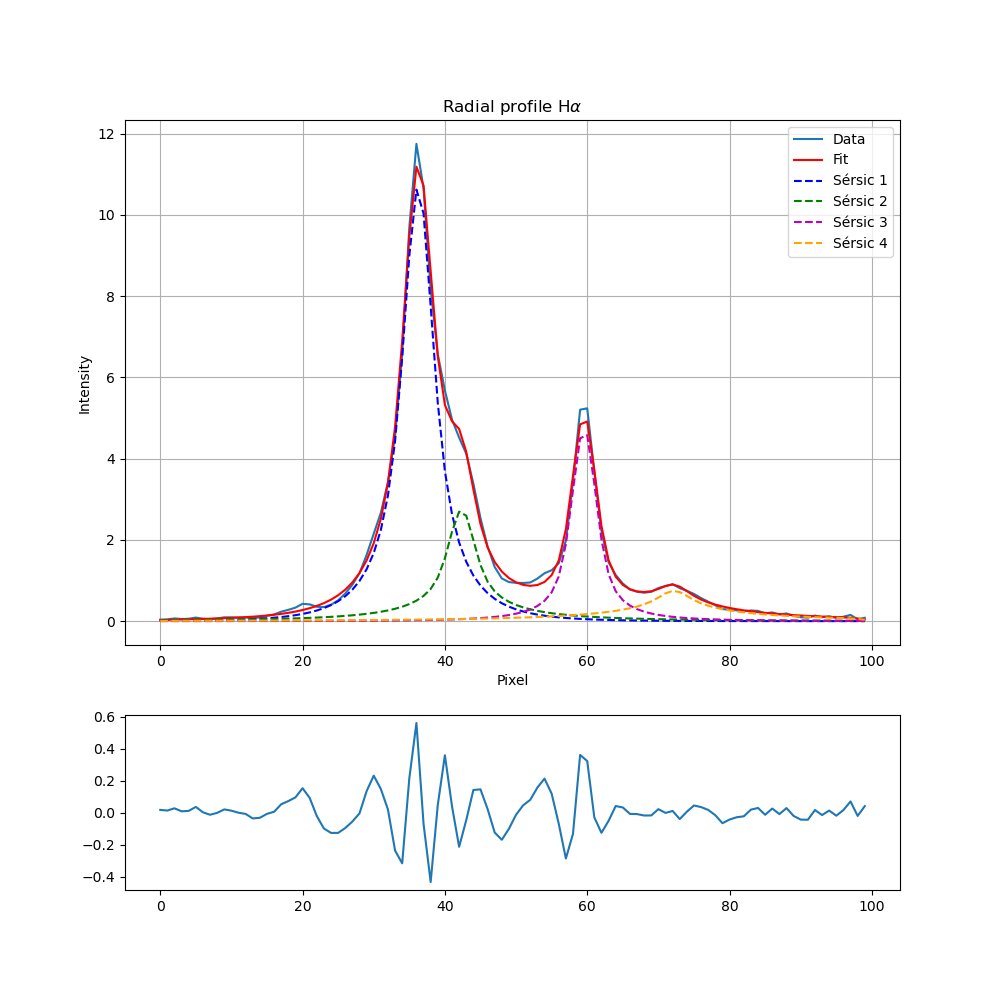

In [36]:
# Plots:
params_curve_4, covariance_4 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params4, 
                                         sigma = real_errors)

print("Optimize parameters with curve fit:")

chi_quadr[3], red_chi[3] = save_params(params_curve_4, covariance_4, radial_profile_HA, real_errors, x_axes, 4, line_name="Four", output_prefix="fit")

aic[3] = AIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
bic[3] = BIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
print(aic[3], chi_quadr[3], bic[3], len(params_curve_4))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_4)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_4')

In [37]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =  [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (50, 70),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (70, 80),
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (19, 21),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params5 = result.x

print("Optimize parameters with differential_evolution:", best_params5)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 146791.5800686517
differential_evolution step 2: f(x)= 128329.88009184848
differential_evolution step 3: f(x)= 46909.51105440634
differential_evolution step 4: f(x)= 46909.51105440634
differential_evolution step 5: f(x)= 19979.059021335874
differential_evolution step 6: f(x)= 19979.059021335874
differential_evolution step 7: f(x)= 19415.96141953534
differential_evolution step 8: f(x)= 11205.445612863225
differential_evolution step 9: f(x)= 11205.445612863225
differential_evolution step 10: f(x)= 11205.445612863225
differential_evolution step 11: f(x)= 11205.445612863225
differential_evolution step 12: f(x)= 4915.294751535153
differential_evolution step 13: f(x)= 4915.294751535153
differential_evolution step 14: f(x)= 4915.294751535153
differential_evolution step 15: f(x)= 4915.294751535153
differential_evolution step 16: f(x)= 4915.294751535153
differential_evolution step 17: f(x)= 4915.294751535153
differential_evolution step 18: f(x)= 767.80698351

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18716\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18716\3428358457.py:11: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=1.5958, r_e=6.2430, n=1.4021, x_0=36.2741
Sérsic 2: I_e=0.0849, r_e=17.0739, n=2.5343, x_0=42.5032
Sérsic 3: I_e=0.0400, r_e=31.2749, n=3.8148, x_0=59.5634
Sérsic 4: I_e=0.0199, r_e=48.5344, n=2.2785, x_0=72.3919
Sérsic 5: I_e=3.5536, r_e=0.0111, n=3.7949, x_0=19.0338
[2.37884025e-01 6.90309087e-01 1.21684714e-01 6.98882114e-02
 2.22922521e-01 4.18373263e+01 1.76804290e+00 1.83627525e-01
 4.55438944e-01 2.59594396e+02 1.06969746e+01 4.77314111e-04
 2.80790056e-02 1.09800235e+02 9.33128742e-01 3.18349876e-01
 7.65285016e+05 1.39178305e+03 4.77800642e+05 1.91029165e+02]
0.9324604884600213
51.56537188086509 0.9324604884600213 93.03586420822187 20


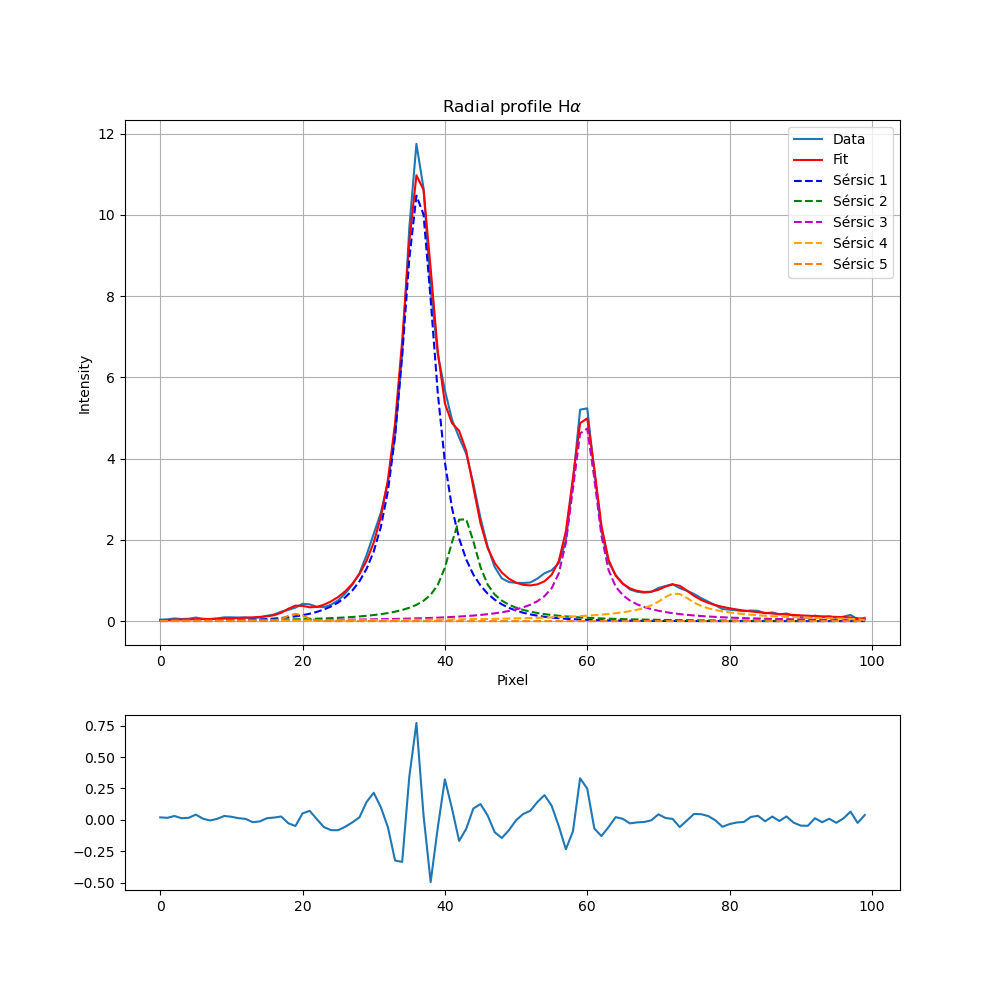

In [38]:
# Plots:
params_curve_5, covariance_5 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params5,
                                         sigma = real_errors)

print("Optimize parameters with curve fit:")

chi_quadr[4], red_chi[4] = save_params(params_curve_5, covariance_5, radial_profile_HA, real_errors, x_axes, 5, line_name="Five", output_prefix="fit")

aic[4] = AIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
bic[4] = BIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
print(aic[4], chi_quadr[4], bic[4], len(params_curve_5))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_5)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[16:20]),  linestyle='--', label='Sérsic 5')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_5')

In [39]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (50, 70),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (70, 80),
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (19, 21),   # x_0: posizione da 0 a 100   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params6 = result.x

print("Optimize parameters with differential_evolution:", best_params6)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 154976.9156063302
differential_evolution step 2: f(x)= 62037.628800822626
differential_evolution step 3: f(x)= 62037.628800822626
differential_evolution step 4: f(x)= 62037.628800822626
differential_evolution step 5: f(x)= 62037.628800822626
differential_evolution step 6: f(x)= 6198.717973534547
differential_evolution step 7: f(x)= 6198.717973534547
differential_evolution step 8: f(x)= 6198.717973534547
differential_evolution step 9: f(x)= 6198.717973534547
differential_evolution step 10: f(x)= 5922.871077572968
differential_evolution step 11: f(x)= 5922.871077572968
differential_evolution step 12: f(x)= 5868.546180508405
differential_evolution step 13: f(x)= 5168.955578877418
differential_evolution step 14: f(x)= 5168.955578877418
differential_evolution step 15: f(x)= 2491.188335784668
differential_evolution step 16: f(x)= 2491.188335784668
differential_evolution step 17: f(x)= 2491.188335784668
differential_evolution step 18: f(x)= 2491.1883357846

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18716\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18716\1779277057.py:12: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18716\111436280.py:9: RuntimeWarning: overflow encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_18716\111436280.py:9: RuntimeWarning: overflow encountered in multiply
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with curve fit:
Sérsic 1: I_e=0.5292, r_e=14.6617, n=2.2217, x_0=36.1750
Sérsic 2: I_e=2.0049, r_e=2.1792, n=0.1454, x_0=42.0468
Sérsic 3: I_e=0.1377, r_e=7.4653, n=3.2371, x_0=59.5634
Sérsic 4: I_e=0.3055, r_e=2.3998, n=0.2661, x_0=72.7826
Sérsic 5: I_e=-0.0185, r_e=35.7485, n=2.0044, x_0=25.2395
Sérsic 6: I_e=0.1754, r_e=22.5704, n=0.7363, x_0=62.2610
[4.55793792e-01 1.09935847e+01 5.97004816e-01 8.60514839e-02
 1.14879927e-01 9.43660336e-01 2.62265059e-01 2.81053177e-01
 1.53214222e+00 5.66734156e+01 1.32818018e+01 1.02555110e-03
 1.27989450e-01 4.07269097e-01 3.69102134e-01 2.67403242e-01
 2.45997069e-02 6.29188642e+01 8.40715849e-01 5.08168001e-01
 1.78884799e-01 4.64726520e+00 2.92842564e-01 7.59704840e+00]
0.6058461041911941
64.60584610419119 0.6058461041911941 111.1299305679054 24


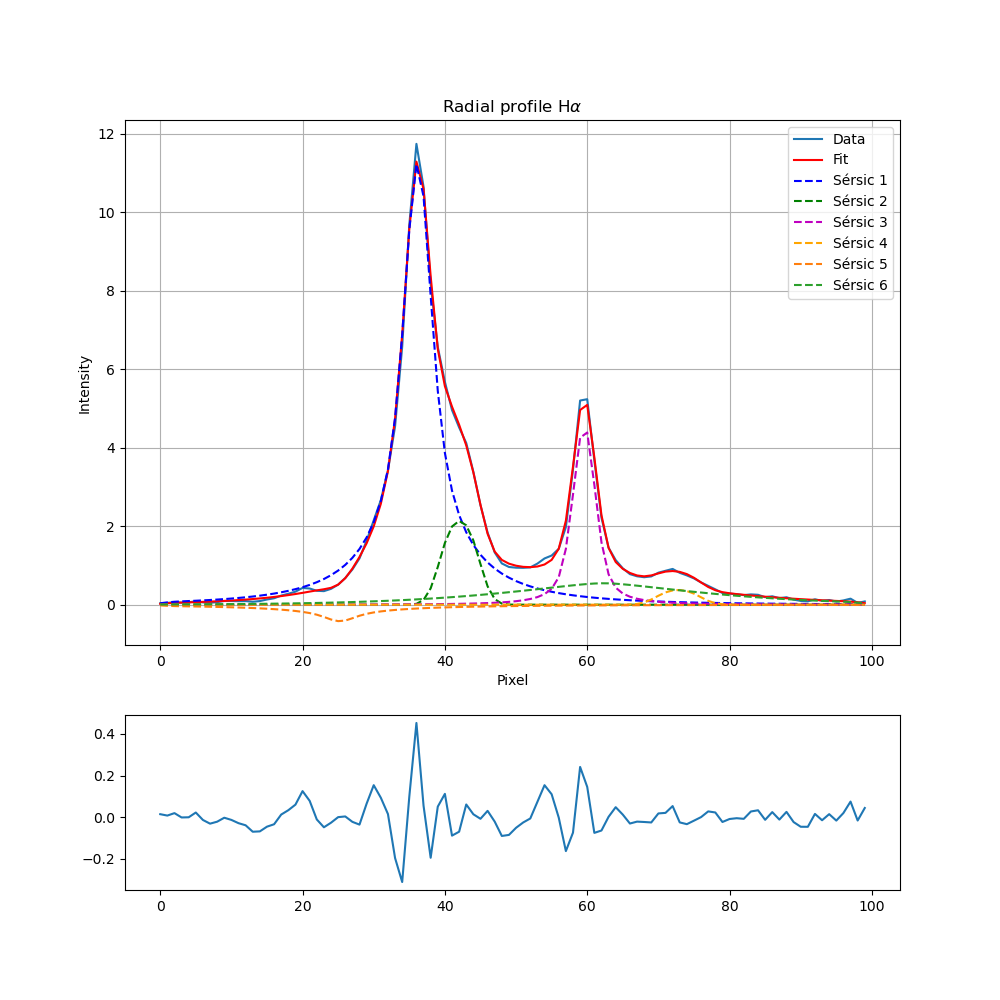

In [40]:
# Plots:
params_curve_6, covariance_6 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params6, 
                                         sigma = real_errors)

print("Optimize parameters with curve fit:")

chi_quadr[5], red_chi[5] = save_params(params_curve_6, covariance_6, radial_profile_HA, real_errors, x_axes, 6, line_name="Six", output_prefix="fit")

aic[5] = AIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
bic[5] = BIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
print(aic[5], chi_quadr[5], bic[5], len(best_params6))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_6)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[20:24]),  linestyle='--', label='Sérsic 6')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_6')

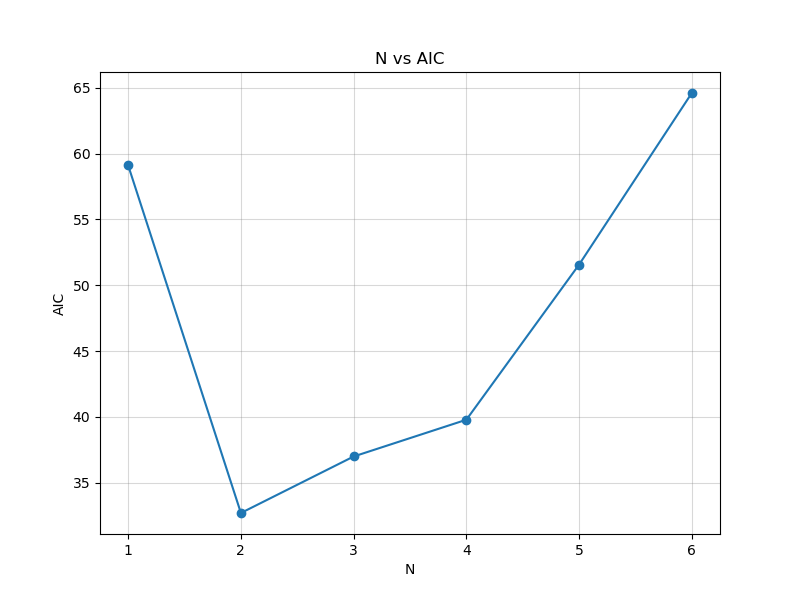

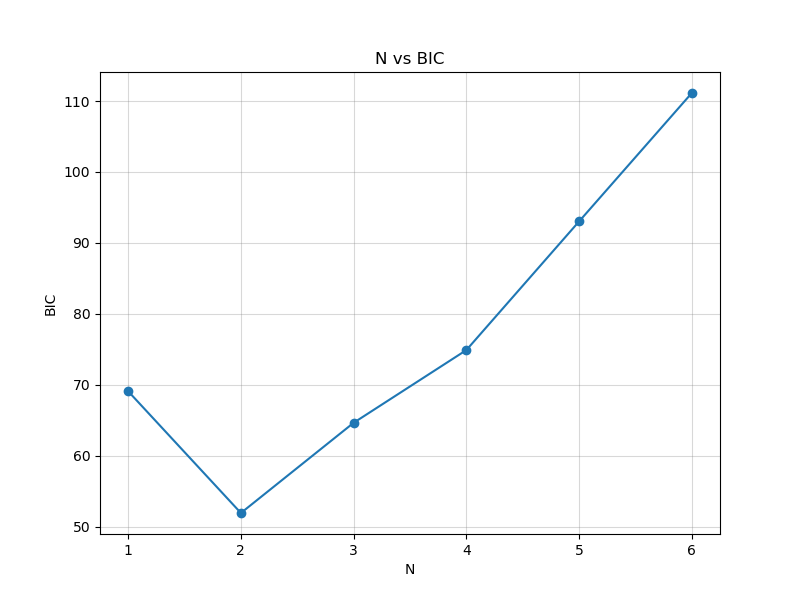

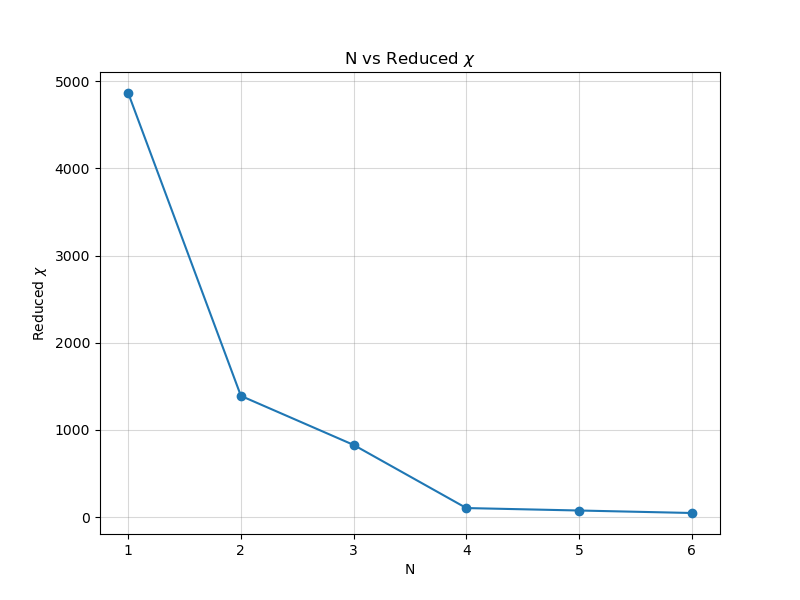

In [41]:
#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6]

fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('AIC')
ax1.set_title('N vs AIC')
ax1.plot(n, aic, marker = 'o')
plt.savefig('AIC_vs_N')
np.savetxt('AIC', aic)
np.savetxt('Reduced_chi', red_chi)

#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6]

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('BIC')
ax2.set_title('N vs BIC')
ax2.plot(n, bic, marker = 'o')
plt.savefig('BIC_vs_N')
np.savetxt('BIC', aic)

fig3 = plt.figure(figsize=(8,6))
ax3 = fig3.gca()
ax3.grid(alpha=0.3, c = 'grey')
ax3.set_xlabel('N')
ax3.set_ylabel('Reduced $\chi$')
ax3.set_title('N vs Reduced $\chi$')
ax3.plot(n, red_chi, marker = 'o')
plt.savefig('Reduced_chi_vs_N')

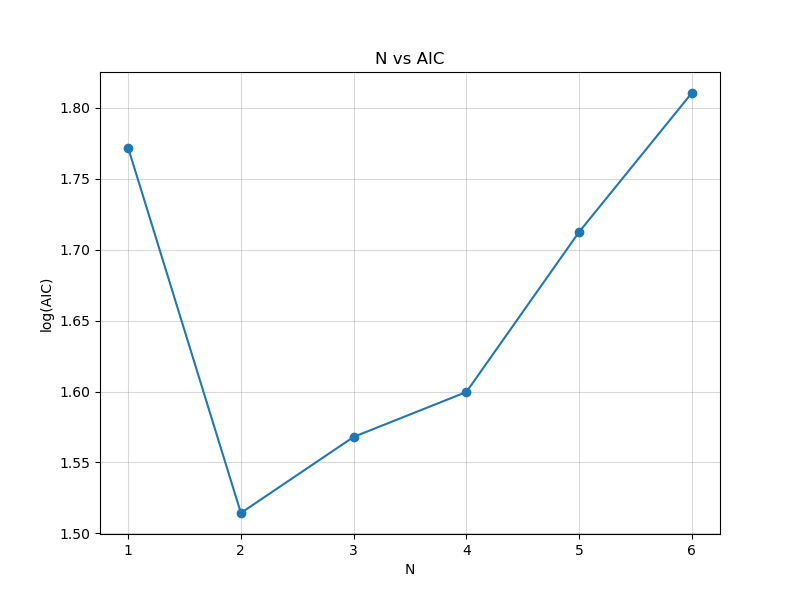

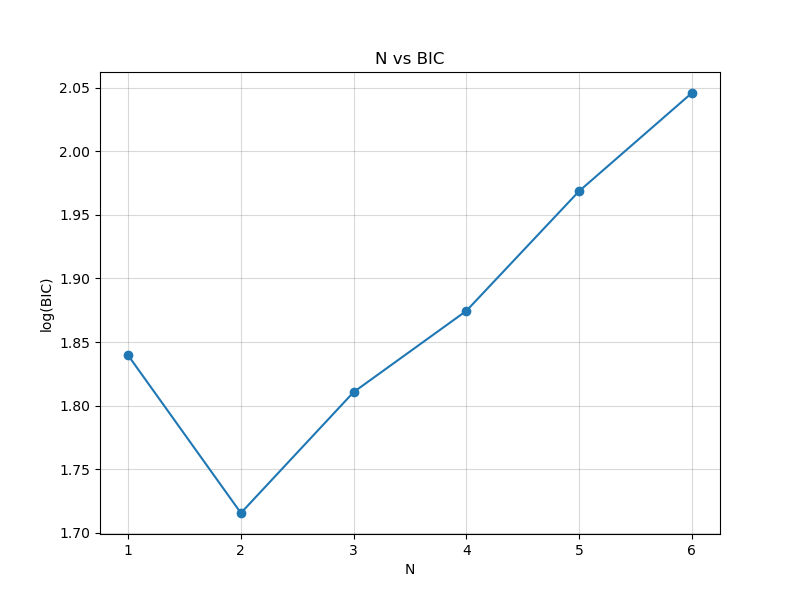

In [42]:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('log(AIC)')
ax1.set_title('N vs AIC')
ax1.plot(n, np.log10(aic), marker = 'o')
plt.savefig('AIC_vs_N_log')

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('log(BIC)')
ax2.set_title('N vs BIC')
ax2.plot(n, np.log10(bic), marker = 'o')
plt.savefig('BIC_vs_N_log')